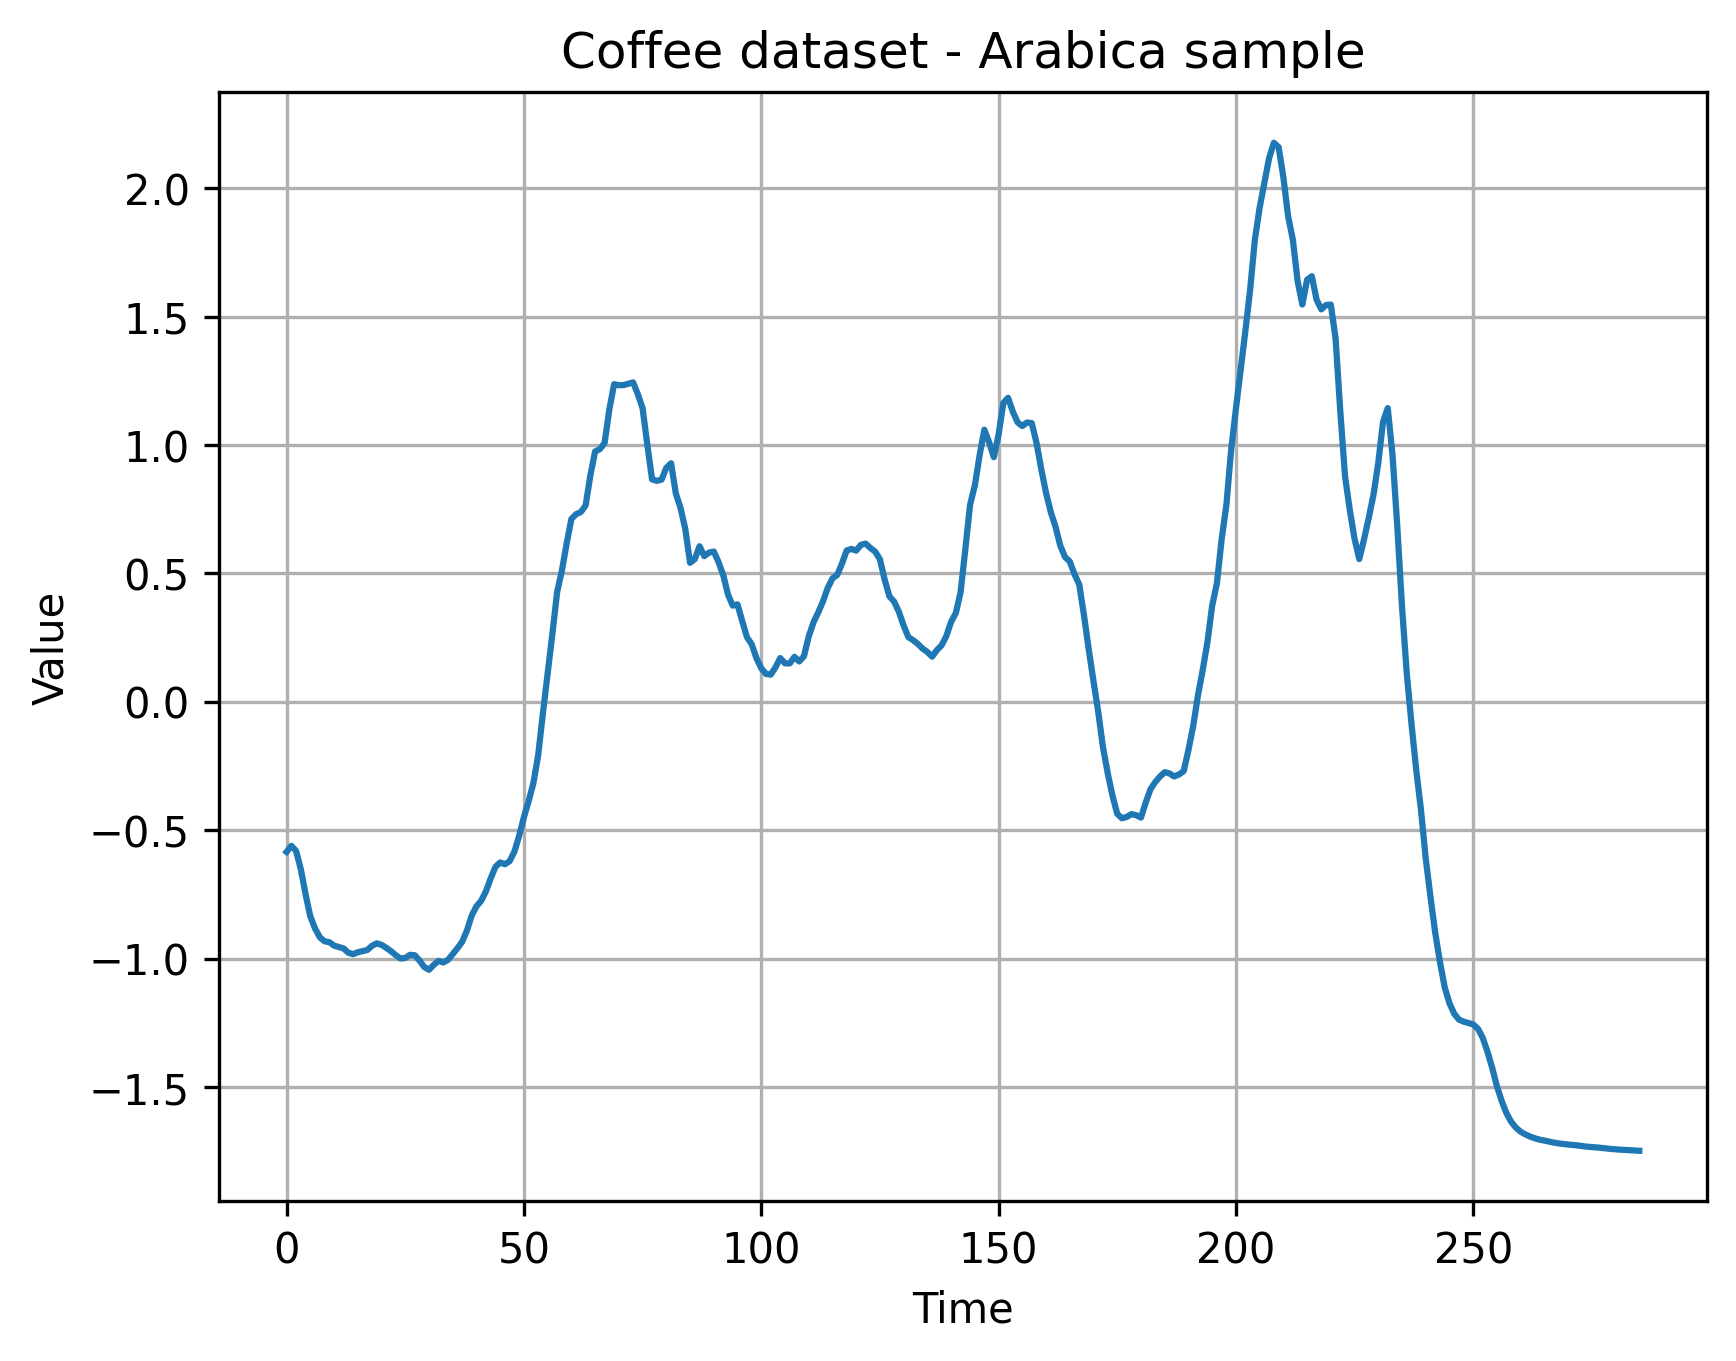

0


In [3]:
from aeon.datasets import load_from_ts_file

from models.tsai.MINIROCKET_Pytorch import MiniRocket

X,y = load_from_ts_file("/home/davide/Downloads/Coffee/Coffee_TRAIN.ts")

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import matplotlib.pyplot as plt

plt.plot(X[13,0,:])
plt.grid(True)
plt.title("Coffee dataset - Arabica sample")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()
print(y[13])

In [4]:
import numpy as np
CMJ = np.load("/home/davide/Downloads/CMJ_resampled.npy",allow_pickle=True).item()
X = CMJ['train']['X']
y = CMJ['train']['y']

0


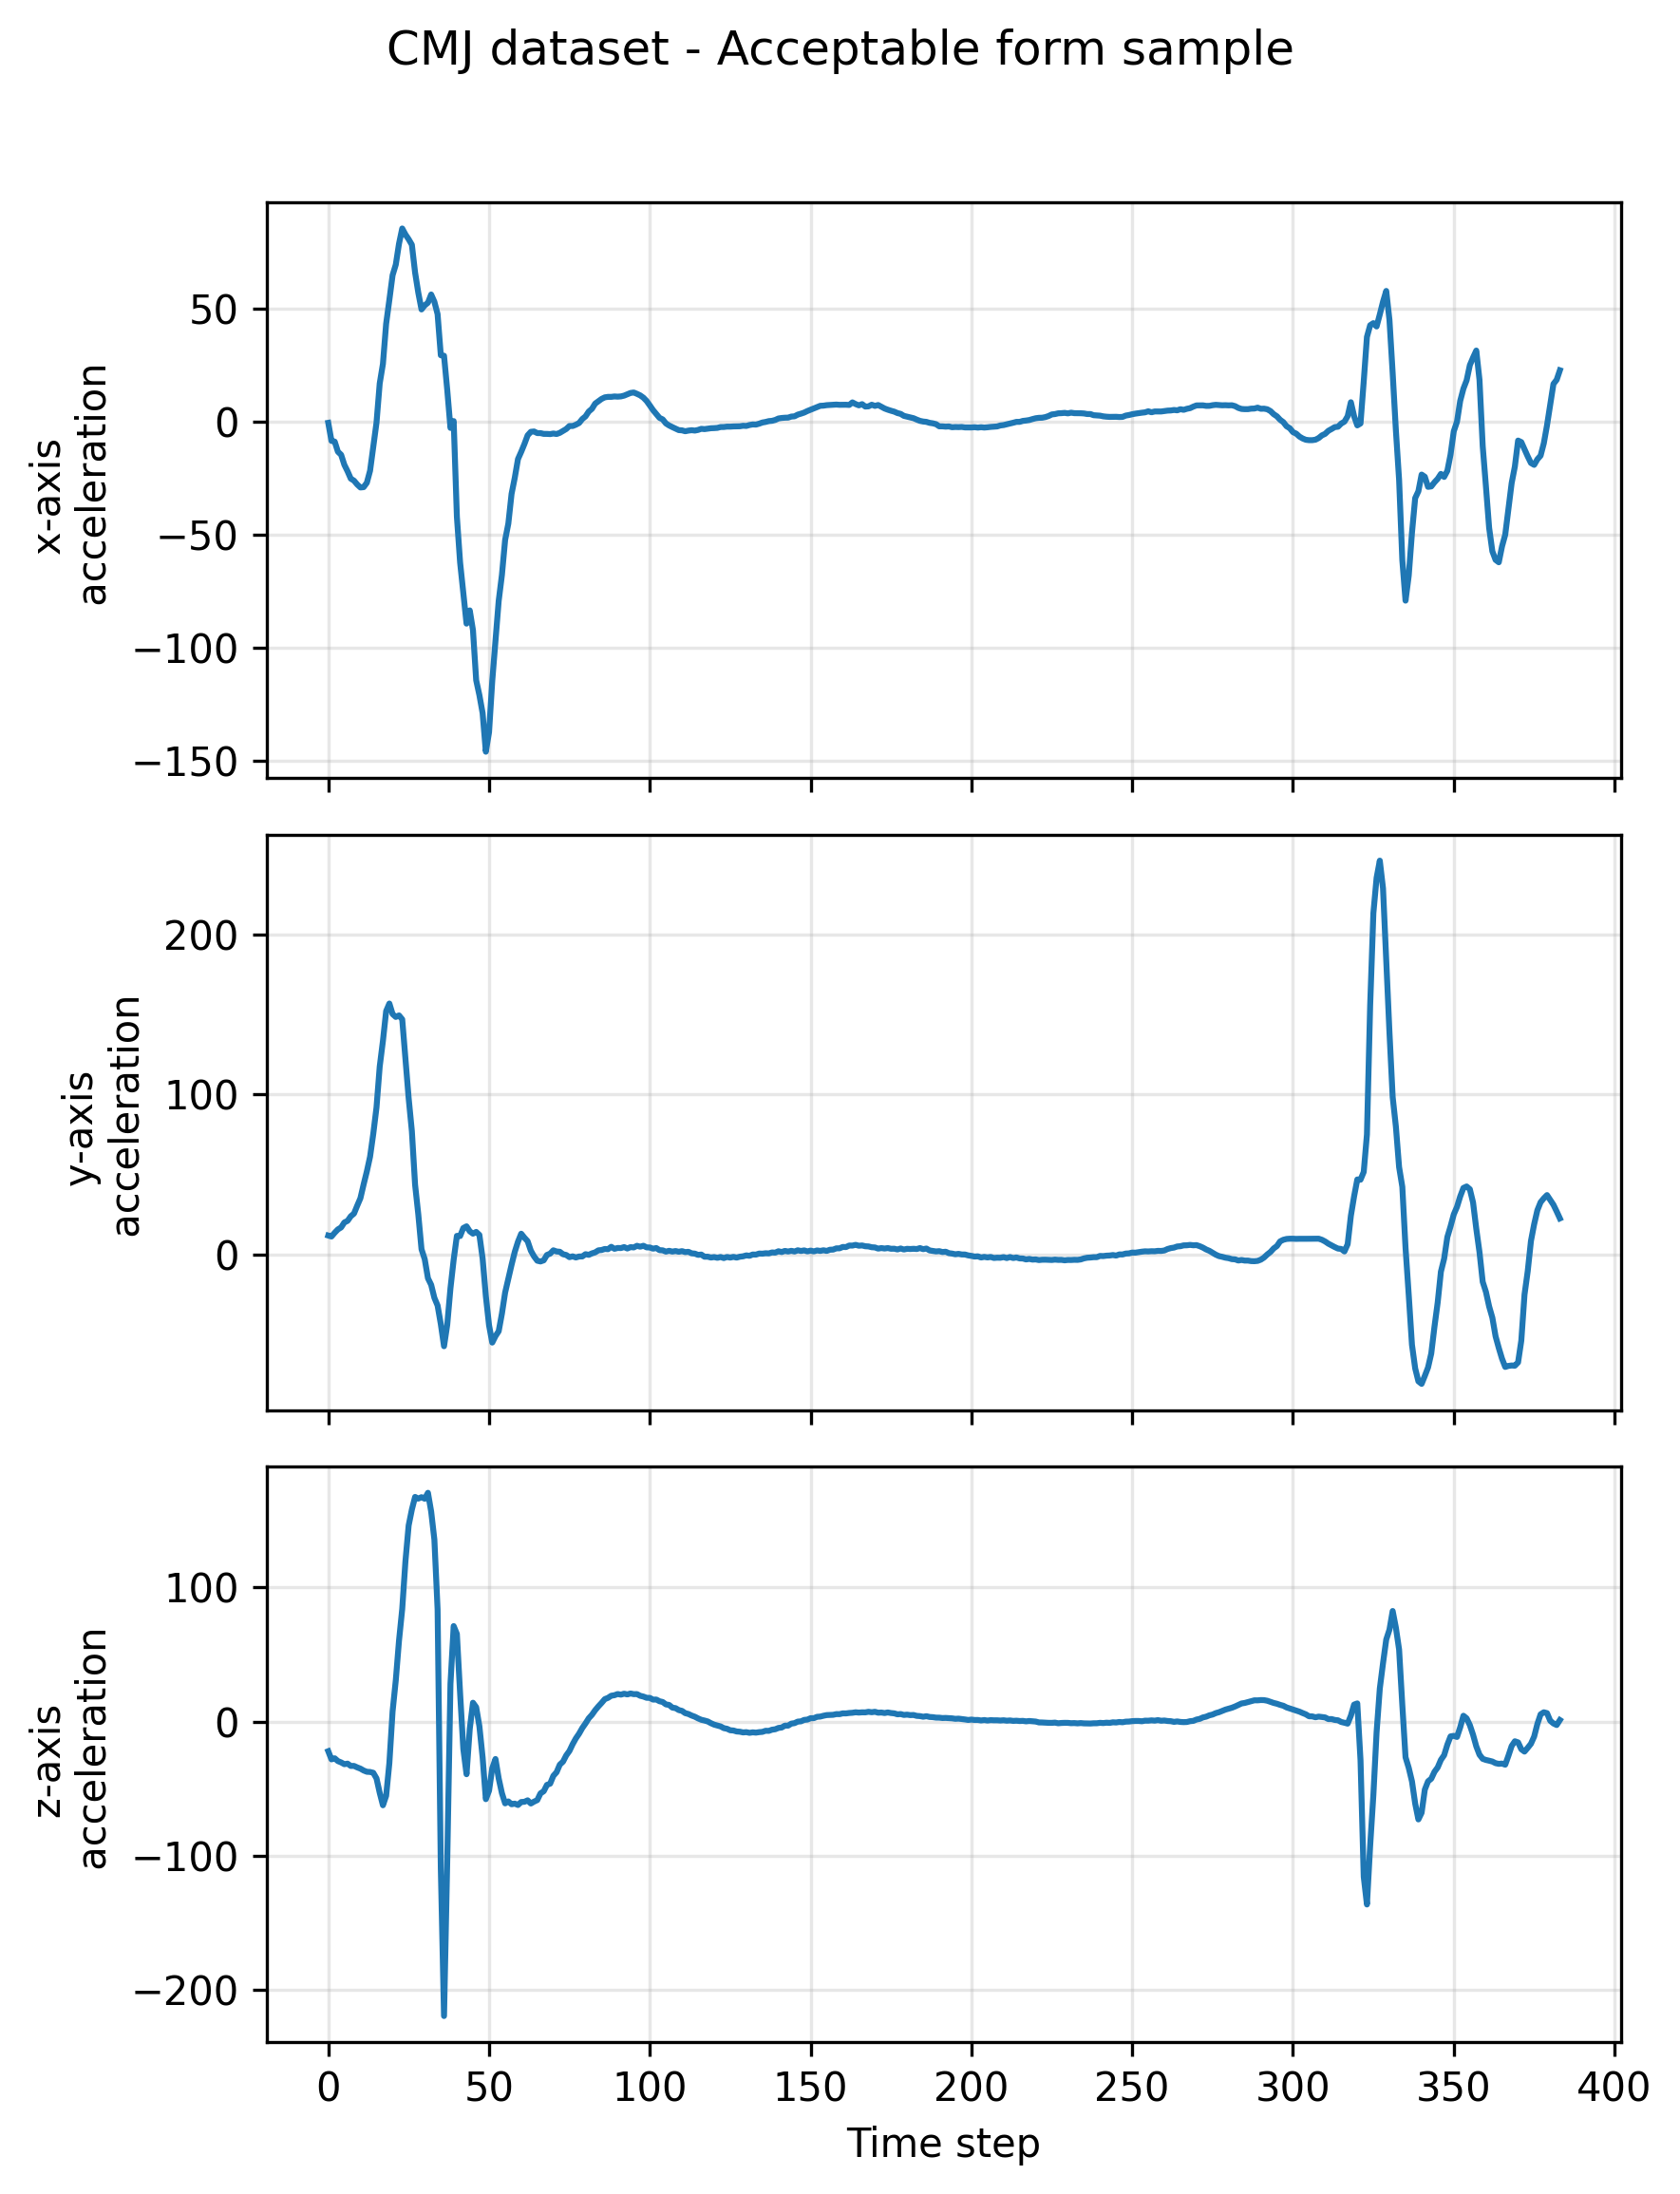

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# CMJ expected shape: (n_samples, timesteps, n_features)
sample_number = 29
sample_idx = sample_number - 1  # 1-based -> 0-based
label = y[sample_idx]
print(label)

sample = X[sample_idx]  # shape: (timesteps, n_features)
n_features, timesteps = sample.shape
x = np.arange(timesteps)

fig, axes = plt.subplots(
    nrows=n_features, ncols=1, figsize=(6, 2.5 * n_features), sharex=True
)

# Handle the case n_features == 1
if n_features == 1:
    axes = [axes]

axis_name = ["x","y","z"]
for i, ax in enumerate(axes):
    ax.plot(x, sample[ i, :], linewidth=1.5)
    ax.set_ylabel(axis_name[i]+"-axis \n acceleration")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time step")
fig.suptitle("CMJ dataset - Acceptable form sample", y=1.02)
plt.tight_layout()
plt.show()

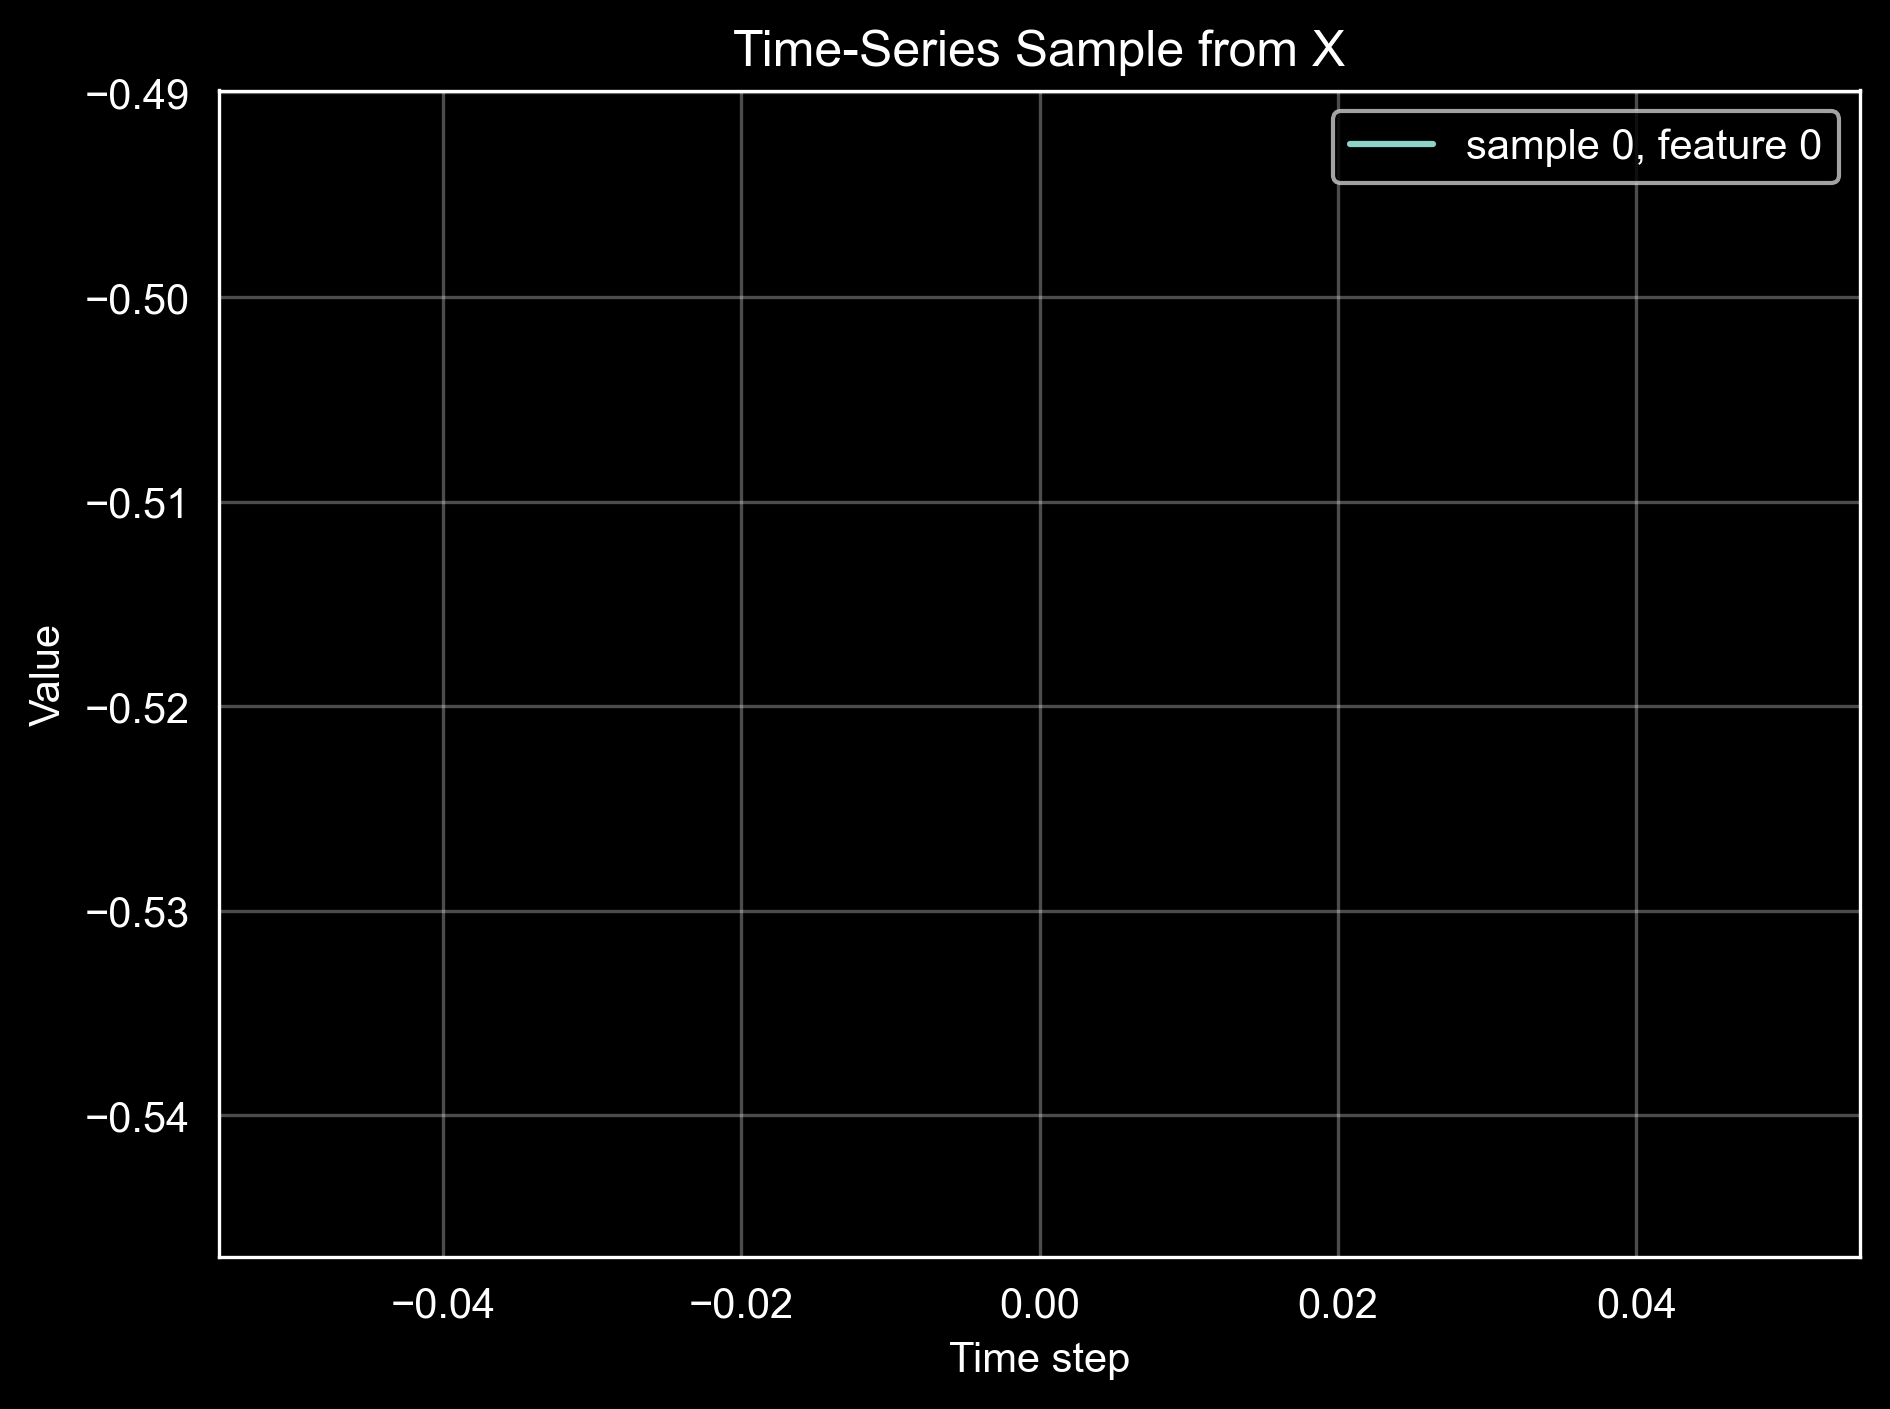

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# X is a NumPy array.
# Expected shapes:
# - (n_samples, timesteps)
# - (n_samples, timesteps, n_features)

sample_idx = 0          # choose which sample to plot
feature_idx = 0         # used only if X is 3D

if X.ndim == 2:
    y = X[sample_idx]
    plt.plot(y, label=f"sample {sample_idx}")
elif X.ndim == 3:
    y = X[sample_idx, :, feature_idx]
    plt.plot(y, label=f"sample {sample_idx}, feature {feature_idx}")
else:
    raise ValueError(f"Unsupported X shape: {X.shape}")

plt.title("Time-Series Sample from X")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Example: create a sample time-series dataset and plot it
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Build a sample dataset
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", periods=200, freq="D")
values = np.cumsum(np.random.randn(200)) + 100  # random-walk style series


# 2) Plot the time series
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["value"], label="Sample series", linewidth=1.8)
plt.title("Sample Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.pipeline import make_pipeline
from aeon.transformations.collection.convolution_based import HydraTransformer
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler


import numpy as np

x = np.random.uniform(0,1,(10,1,100))
y = np.random.uniform(0,1,10)
clf = make_pipeline(
    HydraTransformer(n_kernels=8,
                     n_groups=64,
                     output_type='numpy'),
    StandardScaler(),
    RidgeCV()
)

clf.fit(x,y)

,steps,"[('hydratransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,n_kernels,8
,n_groups,64
,max_num_channels,8
,n_jobs,1
,random_state,None
,output_type,'numpy'
,copy,True


In [30]:
tmp = np.load("/home/davide/Downloads/cappi_rain_rate.npy")
x = np.random.uniform(0,1,(585,200,200))
y = np.random.uniform(0,1,585)



In [32]:
from aeon.regression.convolution_based import MiniRocketRegressor

clf = make_pipeline(
    HydraTransformer(n_kernels=8,
                     n_groups=64,
                     output_type='numpy'),
    StandardScaler(),
    RidgeCV()
)

clf = MiniRocketRegressor()

clf.fit(x,y)

,n_kernels,10000
,max_dilations_per_kernel,32
,estimator,None
,random_state,None
,n_jobs,1
